<a href="https://colab.research.google.com/github/sahilmishra-tech/book-keeping/blob/main/Another_copy_of_Copy_of_Sample_ML_Submission_Template_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Book gne



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual

# **Project Summary -**

---







# Project Summary

This project focuses on analyzing the **Google Books Dataset** using data preprocessing, exploratory data analysis (EDA), dimensionality reduction, and clustering techniques. Initially, the dataset was cleaned by removing duplicate records, handling missing values, and transforming categorical features into numerical form through label encoding. Numerical features were standardized using the **StandardScaler** to ensure equal contribution during clustering.

Exploratory Data Analysis (EDA) was performed to understand the dataset by visualizing distributions of page counts, publication years, publishers, authors, categories, missing values, and correlations among numerical features. These visualizations provided valuable insights into the structure and quality of the data.

To reduce the dimensionality of the dataset while preserving most of the information, **Principal Component Analysis (PCA)** was applied. PCA simplified the high-dimensional data into principal components, making clustering more efficient and enabling effective visualization in two and three dimensions.

The optimal number of clusters was determined using the **Elbow Method**, which suggested **six clusters**. Two clustering algorithms were then implemented: **K-Means Clustering** and **Agglomerative Hierarchical Clustering**. The clustering results were visualized using 2D and 3D PCA scatter plots, along with a dendrogram for hierarchical clustering, to evaluate the separation and structure of the identified clusters.

Overall, this project demonstrates how unsupervised machine learning can be used to discover hidden patterns in a large book dataset. The generated clusters provide meaningful groupings of books based on their attributes, which can support applications such as book recommendation systems, library organization, and market analysis.


# **GitHub Link -**

https://github.com/sahilmishra-tech/book-keeping



# **Problem Statement**


The rapid growth of digital libraries has resulted in the availability of thousands of books with diverse authors, publishers, genres, and publication years. Analyzing such large datasets manually is time-consuming and inefficient. There is a need for an automated approach to discover hidden patterns and group similar books based on their characteristics. Clustering techniques can help organize books into meaningful groups, enabling better recommendation systems, trend analysis, and catalog management. This project aims to preprocess the Google Books dataset, perform exploratory data analysis (EDA), and apply unsupervised machine learning algorithms to identify natural clusters of books.



# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
#clustering model
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

### Dataset Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Dataset
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/google_books_dataset-selected-columns.csv')


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,book_id,title,subtitle,authors,publisher,published_date,description,page_count,categories,average_rating
0,LR_VDQAAQBAJ,Bestsellers,"The Path (bestsellers, free bestsellers, bests...","Ivan King, bestsellers",bestsellers,2017-01-04,"Hear What the Critics are Saying ""Wow, what an...",70.0,Young Adult Fiction,NaN
1,WcjTDQAAQBAJ,Bestsellers,"Hell: A Place Without Hope (bestseller books, ...","Ivan King, bestsellers",bestsellers,2017-01-03,"Hear What the Critics are Saying Wow, very ins...",32.0,Comics & Graphic Novels,NaN
2,4fXUDAAAQBAJ,The Bestseller Code,Anatomy of the Blockbuster Novel,"Jodie Archer, Matthew L. Jockers",Macmillan,2016-09-20,"""What if there was an algorithm that could pre...",253.0,Business & Economics,NaN
3,yIVuDwAAQBAJ,Bestseller,A Century of America's Favorite Books,Robert McParland,Bloomsbury Publishing PLC,2018-12-15,Whether curled up on a sofa with a good myster...,335.0,Literary Criticism,NaN
4,2JHXwAEACAAJ,Bestsellers: Popular Fiction since 1900,NaN,C. Bloom,Palgrave Macmillan,2002-07-09,This guide and reference work of all of the be...,306.0,Literary Criticism,NaN


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(15147, 10)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15147 entries, 0 to 15146
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   book_id         15147 non-null  object 
 1   title           15139 non-null  object 
 2   subtitle        5983 non-null   object 
 3   authors         11622 non-null  object 
 4   publisher       7090 non-null   object 
 5   published_date  14933 non-null  object 
 6   description     8351 non-null   object 
 7   page_count      14933 non-null  float64
 8   categories      12695 non-null  object 
 9   average_rating  857 non-null    float64
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Cou
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
book_id,0
title,8
subtitle,9164
authors,3525
publisher,8057
published_date,214
description,6796
page_count,214
categories,2452
average_rating,14290


### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15147 entries, 0 to 15146
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   book_id         15147 non-null  object 
 1   title           15139 non-null  object 
 2   subtitle        5983 non-null   object 
 3   authors         11622 non-null  object 
 4   publisher       7090 non-null   object 
 5   published_date  14933 non-null  object 
 6   description     8351 non-null   object 
 7   page_count      14933 non-null  float64
 8   categories      12695 non-null  object 
 9   average_rating  857 non-null    float64
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


## 3. ***Data Wrangling***

In [ ]:
df.drop(columns=["subtitle","average_rating"], inplace=True)

df["authors"].fillna("Unknown", inplace=True)
df["publisher"].fillna("Unknown", inplace=True)
df["description"].fillna("Unknown", inplace=True)
df["categories"].fillna("Unknown", inplace=True)

df["page_count"].fillna(df["page_count"].median(), inplace=True)

/tmp/ipykernel_1622/2525921182.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["authors"].fillna("Unknown", inplace=True)
/tmp/ipykernel_1622/2525921182.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
df["published_year"] = pd.to_datetime(
    df["published_date"],
    errors="coerce"
).dt.year

df["published_year"].fillna(
    df["published_year"].median(),
    inplace=True
)

/tmp/ipykernel_1622/1385799340.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["published_year"].fillna(


In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
book_id,15147
title,13144
authors,9026
publisher,2002
description,7981
page_count,1496
categories,1830
published_year,60


In [ ]:
df.drop(columns=["published_date"], inplace=True)

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

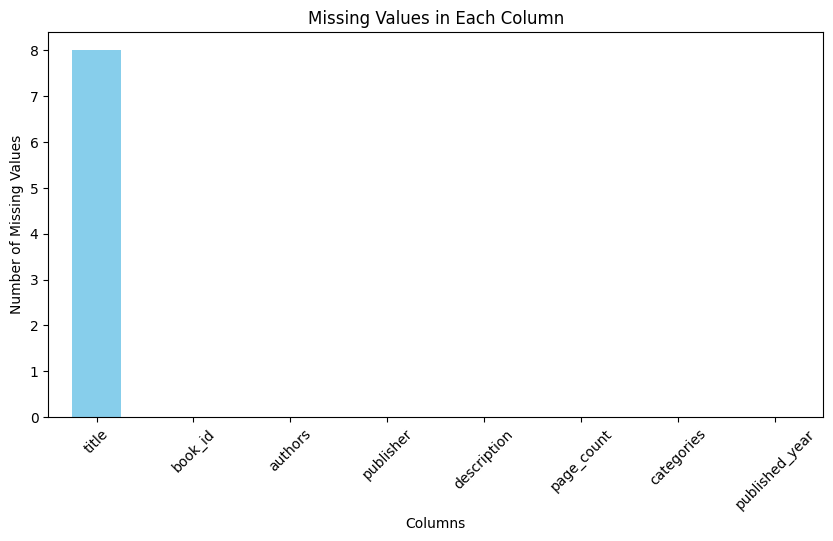

In [ ]:
# Chart - 1 visualization code
import matplotlib.pyplot as plt

missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

<Axes: xlabel='page_count', ylabel='Count'>

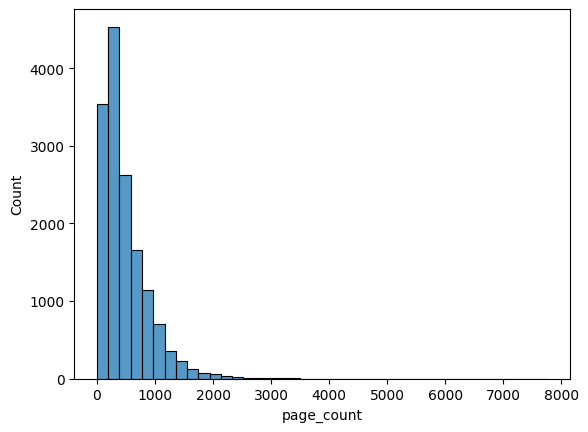

In [ ]:
# Chart - 2 visualization code
sns.histplot(df["page_count"], bins=40)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

<Axes: xlabel='publisher'>

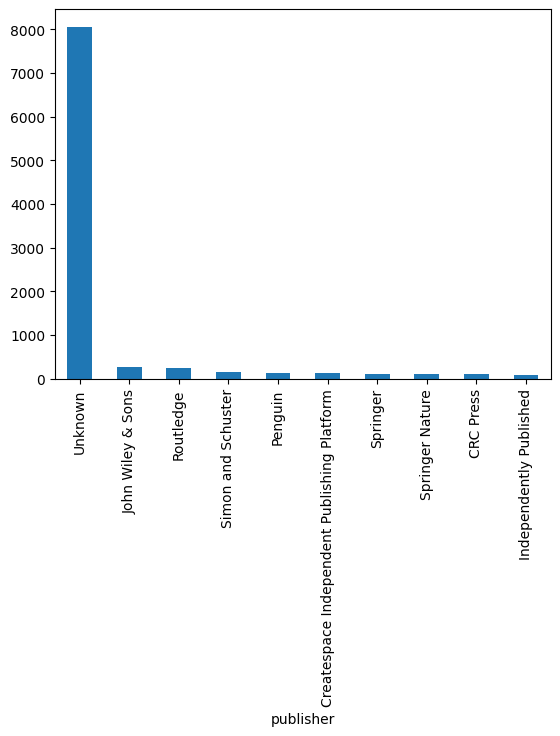

In [ ]:
# Chart - 3 visualization code
df["publisher"].value_counts().head(10).plot(kind="bar")

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

<Axes: xlabel='authors'>

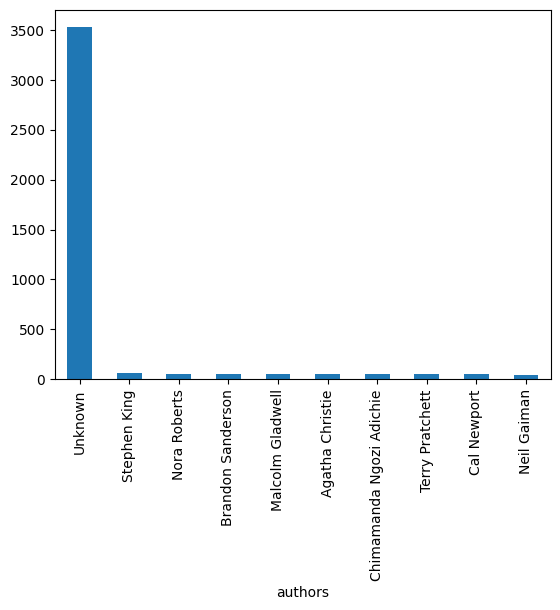

In [ ]:
# Chart - 4 visualization code
df["authors"].value_counts().head(10).plot(kind="bar")

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

<Axes: xlabel='categories'>

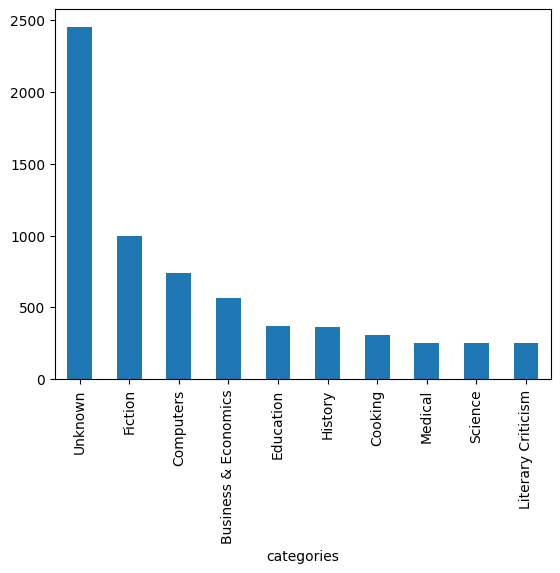

In [ ]:
# Chart - 5 visualization code
df["categories"].value_counts().head(10).plot(kind="bar")

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

<Axes: xlabel='published_year'>

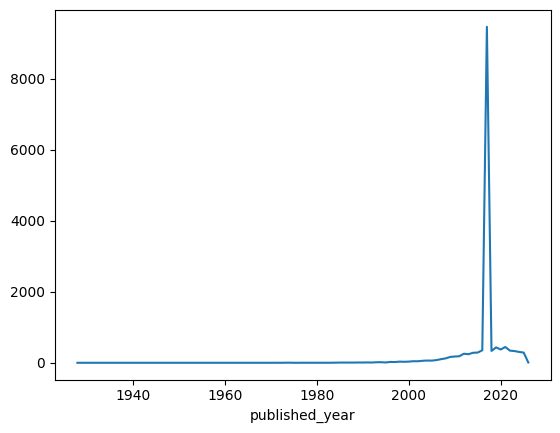

In [ ]:
# Chart - 6 visualization code
df["published_year"].value_counts().sort_index().plot()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

<Axes: xlabel='page_count'>

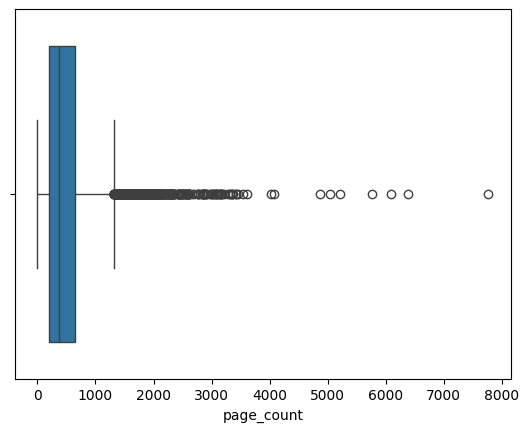

In [ ]:
# Chart - 7 visualization code
sns.boxplot(x=df["page_count"])

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

<Axes: >

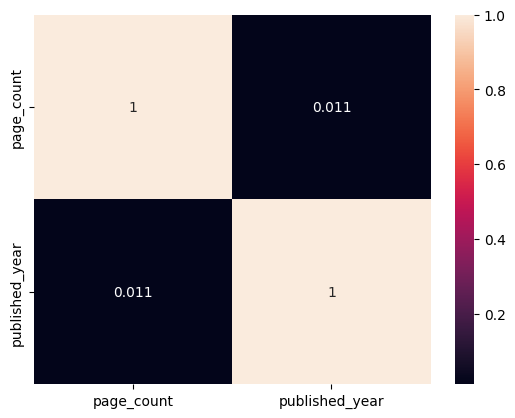

In [ ]:
# Chart - 8 visualization code
sns.heatmap(df.corr(numeric_only=True), annot=True)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

<Axes: ylabel='count'>

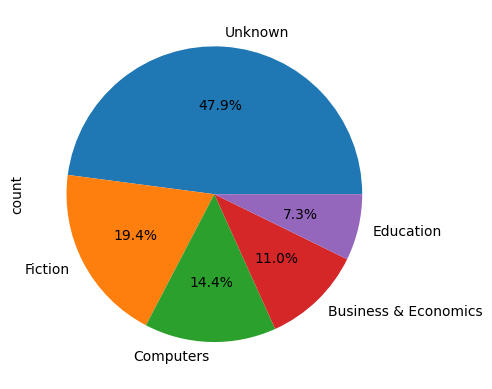

In [ ]:
# Chart - 9 visualization code
df["categories"].value_counts().head(5).plot(kind="pie", autopct="%1.1f%%")

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

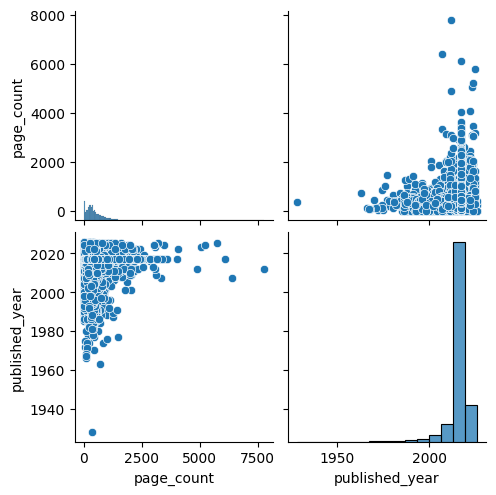

In [ ]:
# Chart - 10 visualization code
sns.pairplot(df.select_dtypes(include="number"))

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["publisher"] = le.fit_transform(df["publisher"])
df["authors"] = le.fit_transform(df["authors"])
df["categories"] = le.fit_transform(df["categories"])

In [ ]:
df = df.drop(columns=[
    "book_id",
    "title",
    "description"
])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("PCA Shape:", X_pca.shape)

PCA Shape: (15147, 5)


## ***7. ML Model Implementation***

In [ ]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.28940096 0.20570692 0.19593605 0.15890108 0.15005499]


In [ ]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.28940096 0.49510789 0.69104393 0.84994501 1.        ]


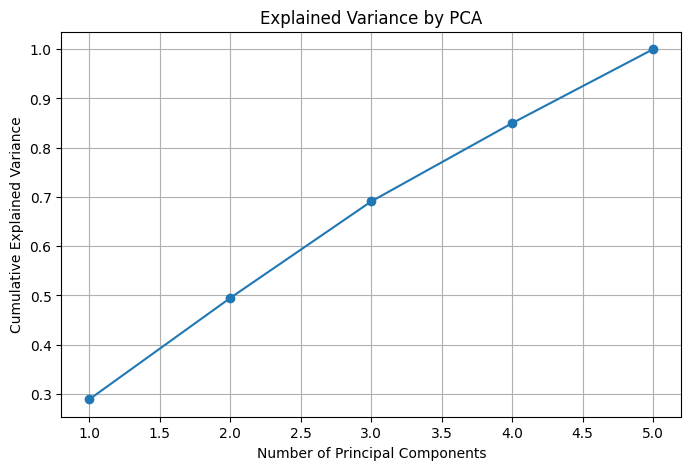

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA")
plt.grid(True)

plt.show()

In [ ]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Components required for 95% variance:", n_components)

Components required for 95% variance: 5


In [ ]:
pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("Final PCA Shape:", X_pca.shape)

Final PCA Shape: (15147, 5)


In [ ]:
print("Variance Retained:", pca.explained_variance_ratio_.sum())

Variance Retained: 0.9655964919587465


# **DENDROGRAM METHOD**

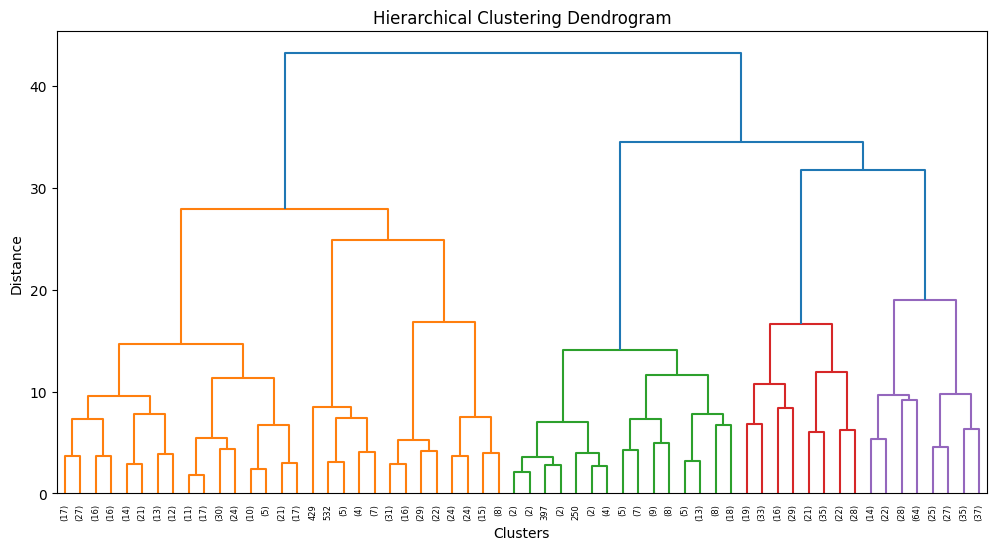

In [ ]:
from sklearn.model_selection import train_test_split

X_sample, _ = train_test_split(
    X_pca,
    train_size=1000,
    random_state=42
)

X_sample.shape
from scipy.cluster.hierarchy import linkage

linked = linkage(
    X_sample,
    method='ward'
)
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt


plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

# **ELBOW METHOD**

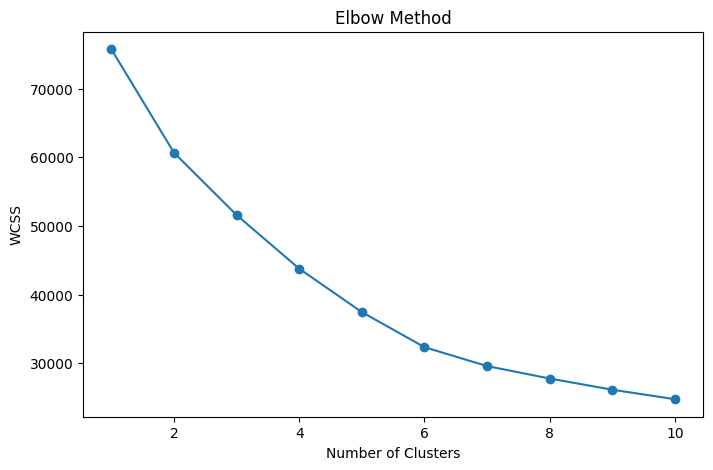

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


inertia=[]

K=range(1,11)


for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# **Agglomerative Clustering**

In [ ]:
from sklearn.model_selection import train_test_split


X_agg_sample, idx = train_test_split(
    X_pca,
    train_size=3000,
    random_state=42
)


from sklearn.cluster import AgglomerativeClustering


agg_model = AgglomerativeClustering(
    n_clusters=6,
    linkage='ward'
)


agg_labels = agg_model.fit_predict(
    X_agg_sample
)


agg_labels[:10]

array([1, 2, 5, 0, 1, 4, 4, 4, 0, 1])

PLOT

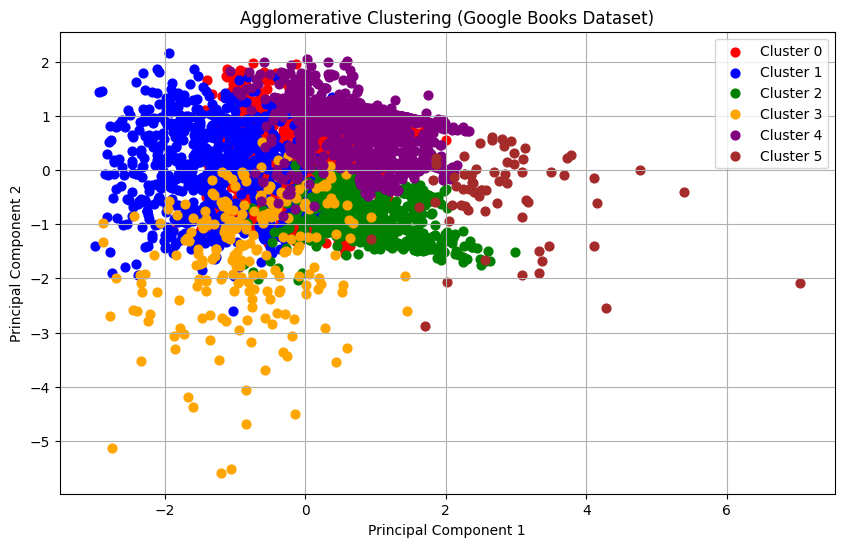

In [ ]:
X_plot = pd.DataFrame(X_agg_sample[: ,:2], columns=['PC1', 'PC2'])
X_plot['Cluster'] = agg_labels

# Plot
plt.figure(figsize=(10,6))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i in range(6):
    plt.scatter(
        X_plot.loc[X_plot['Cluster']==i, 'PC1'],
        X_plot.loc[X_plot['Cluster']==i, 'PC2'],
        s=40,
        c=colors[i],
        label=f'Cluster {i}'
    )
plt.title("Agglomerative Clustering (Google Books Dataset)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

# **K-MEANS CLUSTTERING**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)

kmeans_labels = kmeans.fit_predict(X_pca)

In [ ]:
df['kmeans_cluster'] = kmeans_labels

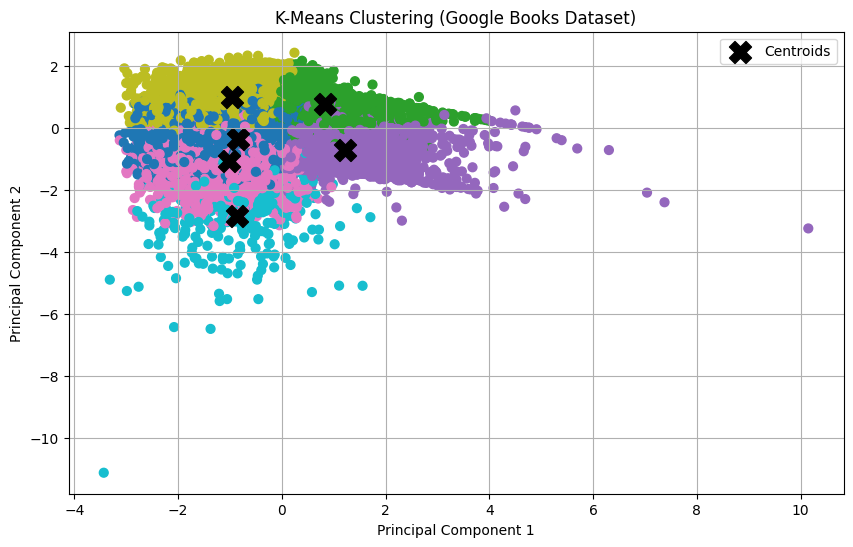

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap='tab10',
    s=40
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (Google Books Dataset)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Create DataFrame
df_kmeans_3d = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3"]
)

df_kmeans_3d["Cluster"] = kmeans_labels.astype(str)

# 3D Scatter Plot
fig = px.scatter_3d(
    df_kmeans_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
    opacity=0.7,
    title="3D K-Means Clustering (Google Books Dataset)"
)

# Add Centroids
fig.add_trace(
    go.Scatter3d(
        x=kmeans.cluster_centers_[:,0],
        y=kmeans.cluster_centers_[:,1],
        z=kmeans.cluster_centers_[:,2],
        mode="markers",
        marker=dict(
            size=10,
            color="black",
            symbol="diamond"
        ),
        name="Centroids"
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    ),
    width=1000,
    height=700
)

fig.show()

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***